# Grover's Algorithm: Quantum Database Search

In this module, you will:
- Understand the core mechanics of **Grover's Algorithm** — a fundamental quantum search algorithm.
- Learn the **mathematical foundation**: Uniform superposition, Oracle phase-flips, and Diffusion (Inversion about average).
- Build and run Grover's search using the QpiAI Quantum SDK's high-level `GroverSearch` class.
- Analyze execution results on a **simulator** and verify accuracy against theoretical success probabilities.
- Explore advanced topics like searching for multiple targets.

## 1. Introduction

Grover's algorithm, discovered by Lov Grover in 1996, provides a **quadratic speedup** for searching unsorted databases. While a classical search requires $O(N)$ operations for a database of $N$ items, Grover's algorithm finds the target in $O(\sqrt{N})$ operations.

### Speedup Comparison

| Database Size ($N$) | Classical Queries | Grover Queries | Speedup |
|-------------------|-------------------|----------------|---------|
| 16 items          | ~16               | ~4             | 4x      |
| 1,024 items       | ~1,024            | ~32            | 32x     |
| 1,000,000 items   | ~1,000,000        | ~1,000         | **1000x** |

---

## 2. Setup & Authentication

As with all QpiAI SDK modules, we begin by loading credentials and authenticating. Ensure your `API_KEY` is present in your `qcloud.env` file.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 3. SDK Primitives Used

- `GroverSearch`: High-level class for configuring and building Grover circuits.
- `Circuit`: Low-level API for gate-based quantum programming.
- `run()`: Executes the circuit on chosen backends (simulators or QPU).
- `visualize()`: Renders histograms and probability distributions from execution results.

## 4. Theory: The Four Stages of Grover

Grover's algorithm iteratively rotates the quantum state toward the target state using the following steps:

### Stage 1: Initialization
Apply Hadamard gates to all $n$ qubits to create a uniform superposition:
$$|s\rangle = H^{\otimes n} |0\rangle^n = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$$

### Stage 2: The Oracle ($U_w$)
The Oracle marks the target state $|w\rangle$ by flipping its phase:
$$U_w |x\rangle = (-1)^{f(x)} |x\rangle, \quad \text{where } f(x) = 1 \iff x = w$$

### Stage 3: The Diffusion Operator ($U_s$)
Performs an "inversion about the average," which amplifies the marked state's amplitude while suppressing others:
$$U_s = 2|s\rangle\langle s| - I$$

### Stage 4: Iteration
The combination $U_s U_w$ is called the **Grover Operator**. It is repeated $k$ times, where the optimal $k$ is:
$$k \approx \frac{\pi}{4} \sqrt{N}$$

### Important: Little-Endian Bit Ordering

**The QpiAI SDK uses little-endian format for qubit ordering:**

- **Bit string `'abc'`** represents: `q[2]=a, q[1]=b, q[0]=c`
- **Rightmost bit** (last character) = **Qubit 0**
- **Leftmost bit** (first character) = **Highest qubit**

**Example:**
Target: `'110'` interpreted as $q_2=1, q_1=1, q_0=0$.

## 5. Implementation: 3-Qubit Search

Let's find the target state `|110⟩` in an 8-item database ($2^3 = 8$).

Algorithm: Grover's Search
Target State: 110
Optimal Iterations: 2


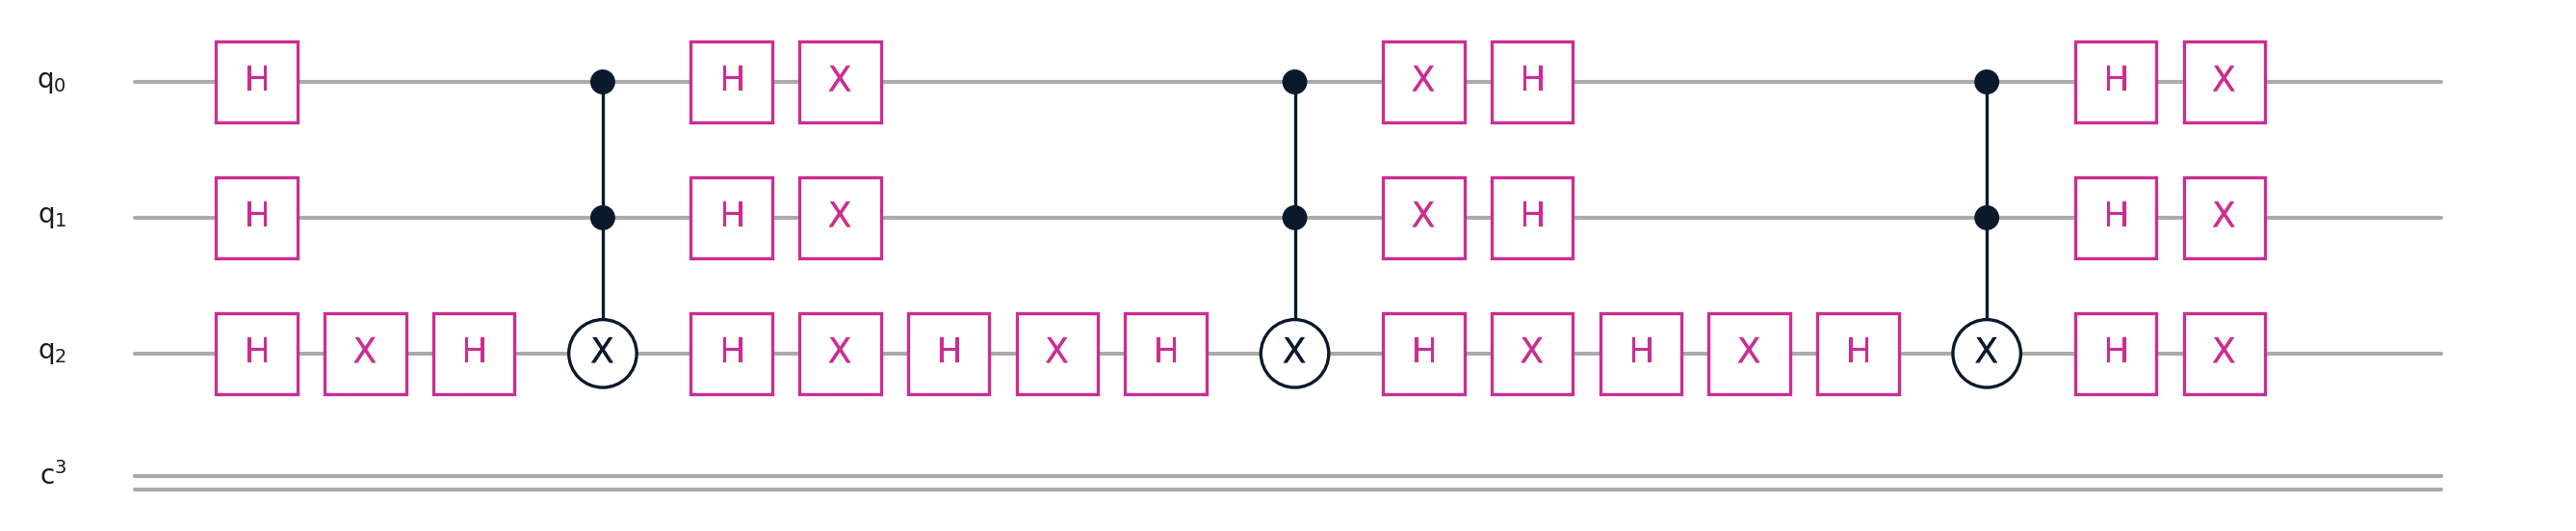

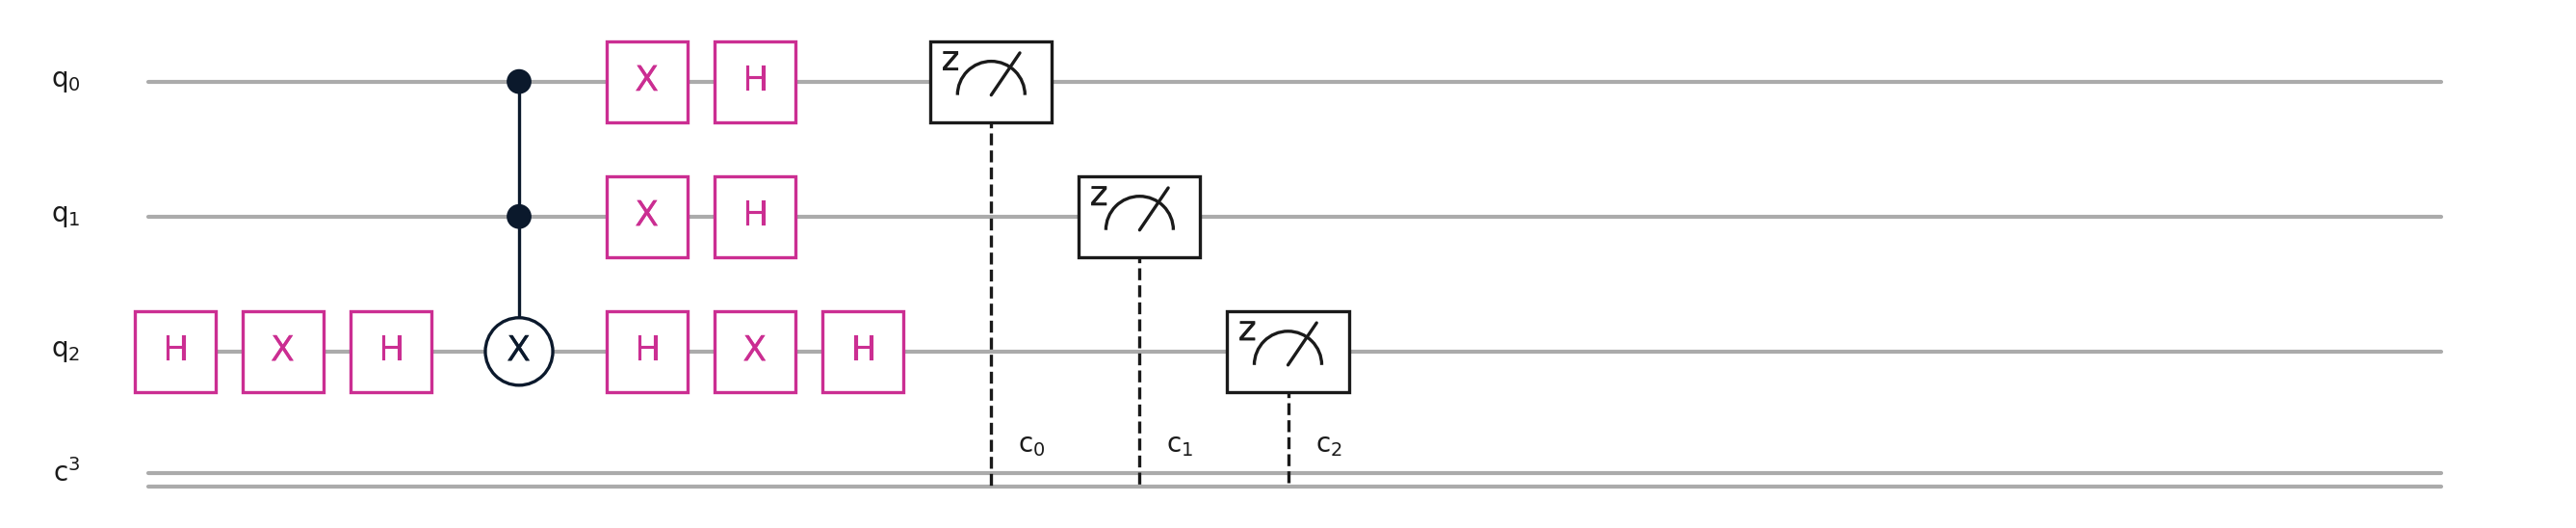

In [2]:
from qpiai_quantum.algorithms import GroverSearch

# Define target and qubits
num_qubits = 3
target = '110'

# Initialize GroverSearch (SDK handles optimal iteration count)
grover = GroverSearch(num_qubits=num_qubits, target=target)

print(f"Algorithm: {grover.name}")
print(f"Target State: {grover.target}")
print(f"Optimal Iterations: {grover.num_iterations}")

# Build and show circuit
circuit = grover.build_circuit()
circuit.show()

### Execution & Visualization
We run the circuit on the `QpiAI-QSV-Simulator` and check the probability distribution.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


Success!
Measured Counts: {'000': 78, '100': 77, '010': 89, '110': 9432, '001': 70, '101': 92, '011': 81, '111': 81}


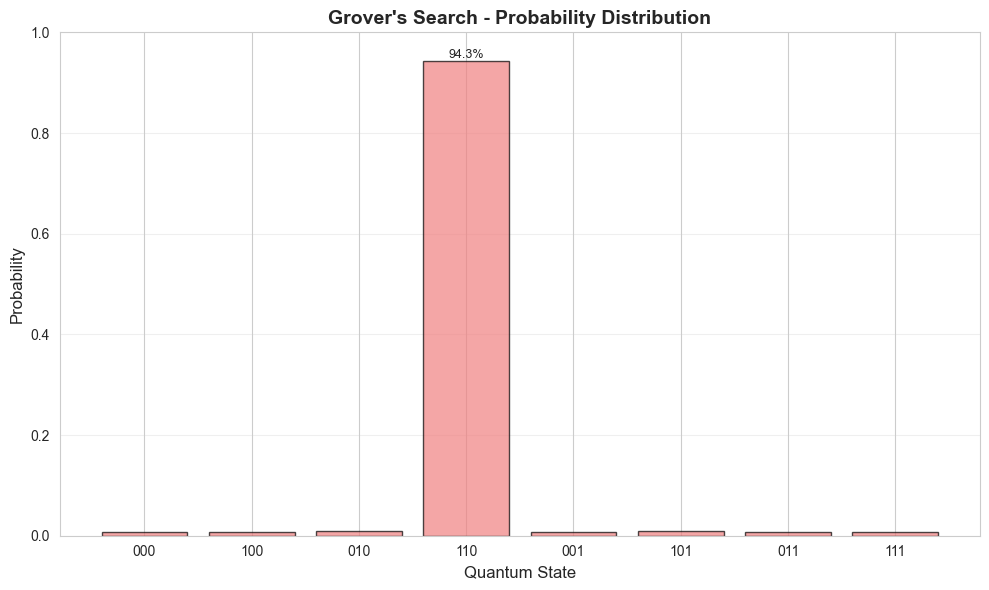

In [3]:
shots = 10000
# Note: experiment_name is only required for cloud executions
result = grover.run(
    shots=shots, 
    device_name="QpiAI-QSV-Local",
    reverse_bits=True
)

print("Success!")
print("Measured Counts:", result.get_counts())

# Visualize probabilities
grover.visualize(plot='probabilities', result=result)

## 6. Verification
We compare the measured success rate with the theoretical probability.

In [4]:
theoretical_success = grover.get_success_probability()
counts = result.get_counts()
measured_success = counts.get(target, 0) / shots

print(f"Theoretical Success Probability: {theoretical_success:.4f}")
print(f"Measured Success Rate:          {measured_success:.4f}")

Theoretical Success Probability: 0.9453
Measured Success Rate:          0.9432


## 7. Advanced: Searching for Different Targets

Grover's algorithm is versatile and can be configured to find any state in the search space. Let's verify this by searching for several different targets in the 3-qubit database.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


Searching for various targets in 3-Qubit Database
Target |000>: Success Rate = 94.26%
Target |011>: Success Rate = 94.92%
Target |101>: Success Rate = 94.66%
Target |111>: Success Rate = 95.04%


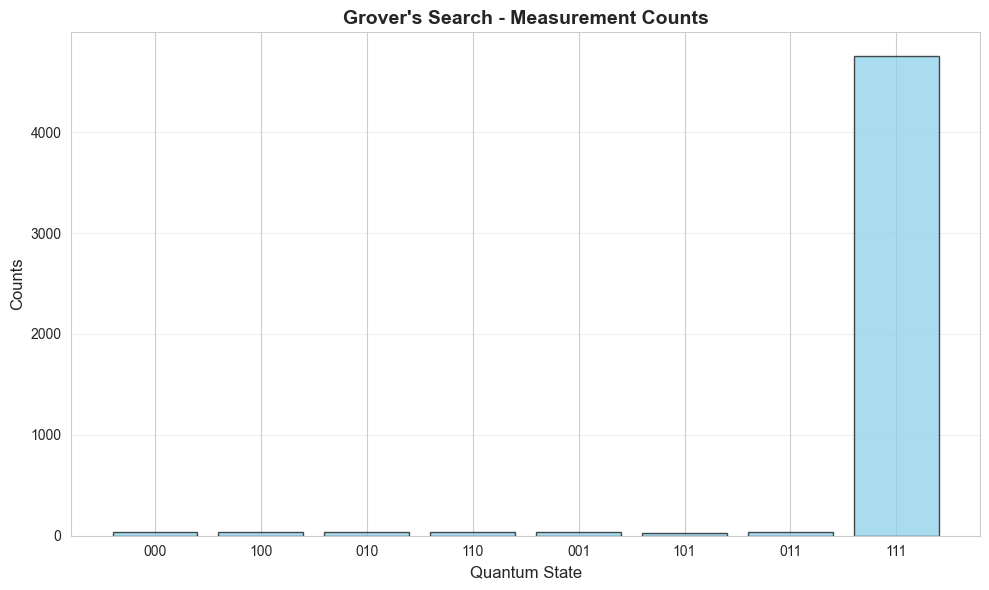

In [5]:
targets = ['000', '011', '101', '111']

print("Searching for various targets in 3-Qubit Database")
print("="*50)

for t in targets:
    # Initialize for each specific target
    gs = GroverSearch(num_qubits=3, target=t)
    
    # Build and run
    gs.build_circuit()
    # Note: experiment_name is only required for cloud executions
    res = gs.run(
        shots=5000, 
        device_name="QpiAI-QSV-Local", 
        reverse_bits=True
    )
    
    counts = res.get_counts()
    success_rate = (counts.get(t, 0) / 5000) * 100
    
    print(f"Target |{t}>: Success Rate = {success_rate:.2f}%")
    
    # Visualize only the last one to keep the output clean
    if t == targets[-1]:
        gs.visualize(plot='histogram', result=res)

## 8. Exercises

1. **Beginner**: Run the 3-qubit search for target `'000'`. Observe the success rate.
2. **Intermediate**: Try a 5-qubit database search. Calculate how many iterations are needed manually and verify with `grover.num_iterations`.
3. **Advanced**: Research how noise on a real QPU (like Indus) affects the success probability compared to the simulator.

## 9. Key Takeaways

- Grover's Algorithm provides a **quadratic speedup** for unstructured search.
- It relies on **Amplitude Amplification** through repeated Oracle and Diffusion steps.
- The number of iterations is critical; too many or too few iterations will decrease the probability of finding the target.
- Little-endian bit ordering is used throughout the QpiAI SDK.

---
**Thank you for learning with QpiAI!**

In [6]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.32
